**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**Loading Dataset From Kaggle** `adhurimquku/ford-car-price-prediction`

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adhurimquku/ford-car-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ford-car-price-prediction' dataset.
Path to dataset files: /kaggle/input/ford-car-price-prediction


In [ ]:
import os
import pandas as pd

filename = os.listdir(path)
print(filename)

['ford.csv']


In [ ]:
file_path = os.path.join(path, filename[0])
df = pd.read_csv(file_path)

In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


**EDA - By Basic**

In [ ]:
df.shape

(17966, 9)

In [ ]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [ ]:
df.isna().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [ ]:
df.duplicated().sum()

np.int64(154)

In [ ]:
df.drop_duplicates(inplace=True)

**EDA - By Visualization**

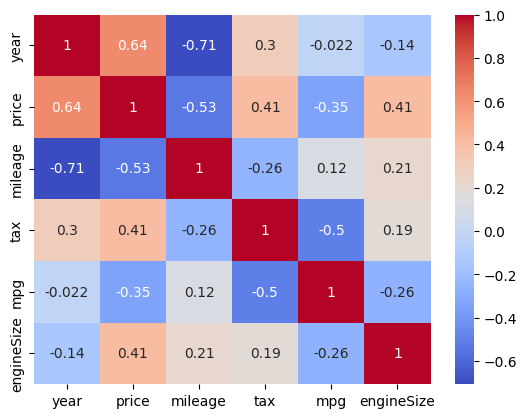

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Focus on Price Dependent Features mainly

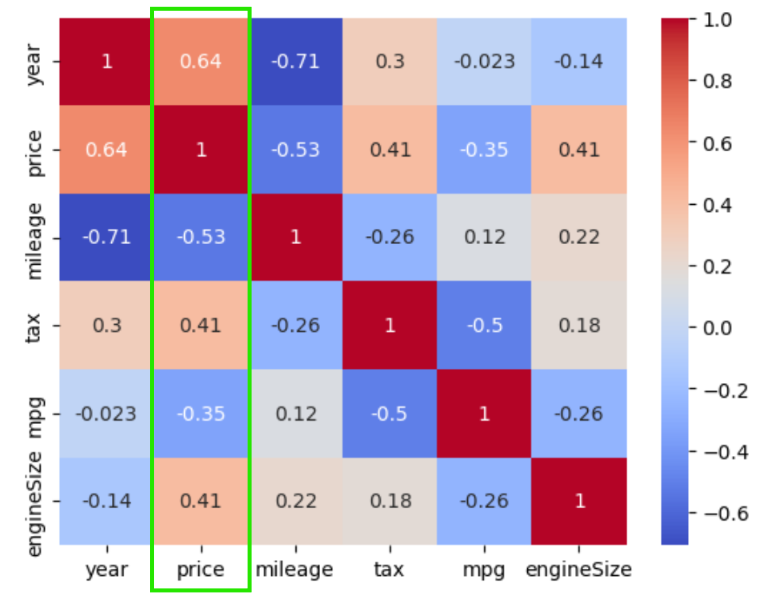

In [ ]:
df.dtypes

,0
model,object
year,int64
price,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64


In [ ]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [ ]:
numeric_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_columns = ['model', 'transmission', 'fuelType']

**Distributions**

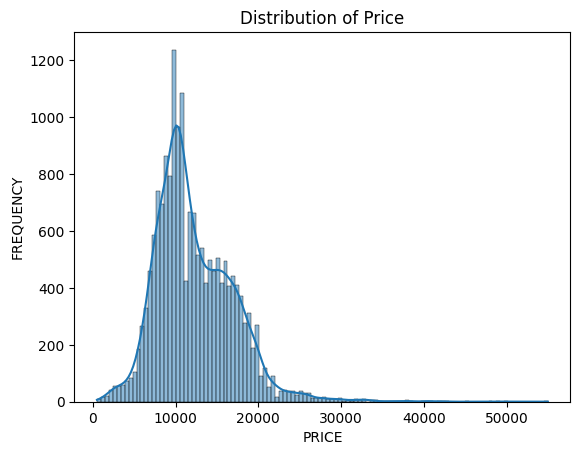

In [ ]:
sns.histplot(data=df, x='price', kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price'.upper())
plt.ylabel('Frequency'.upper())
plt.show()

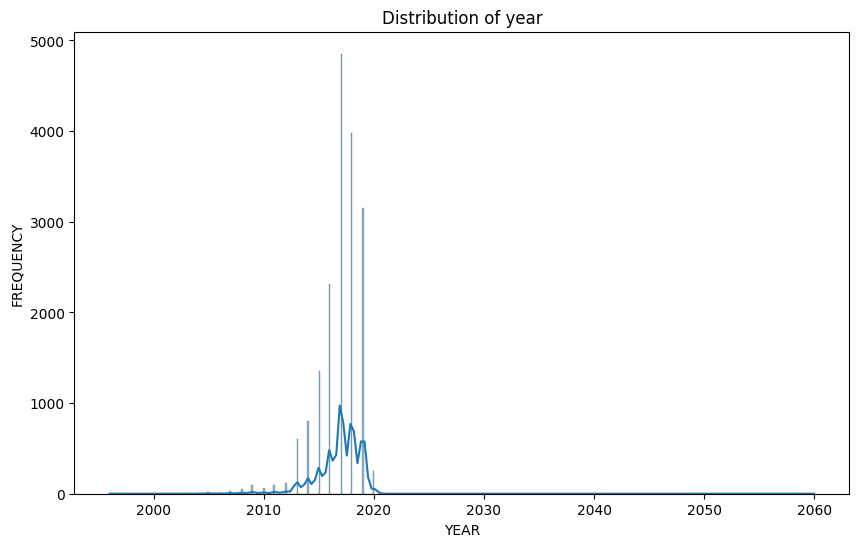

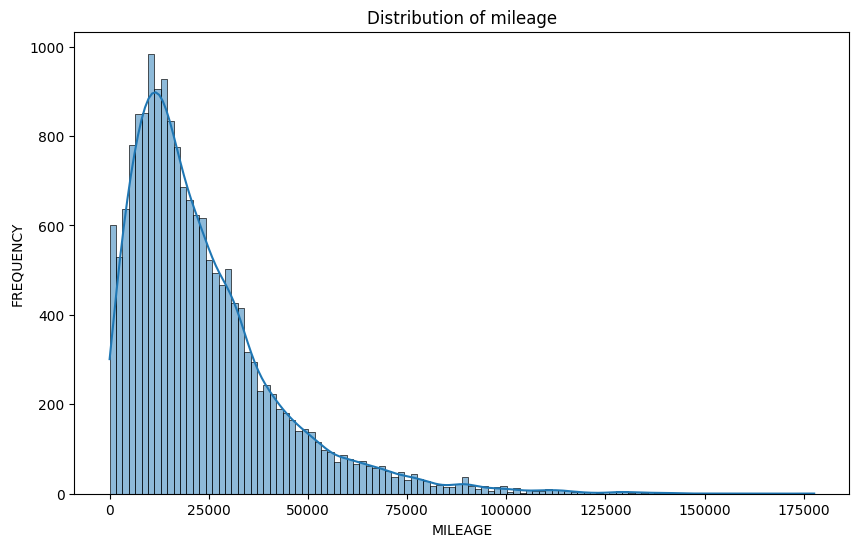

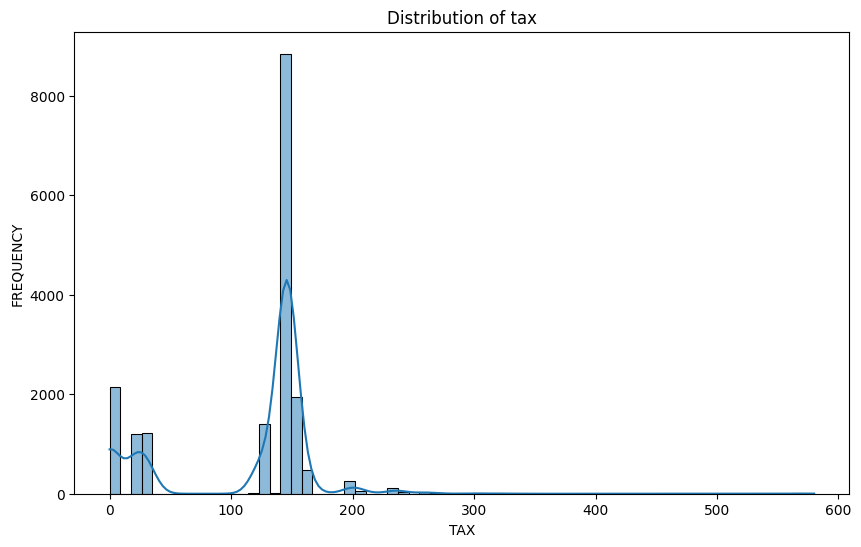

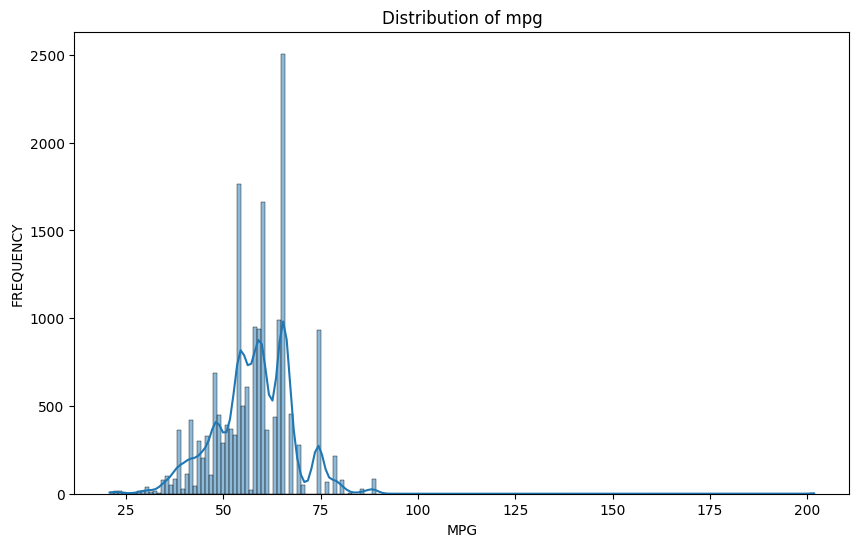

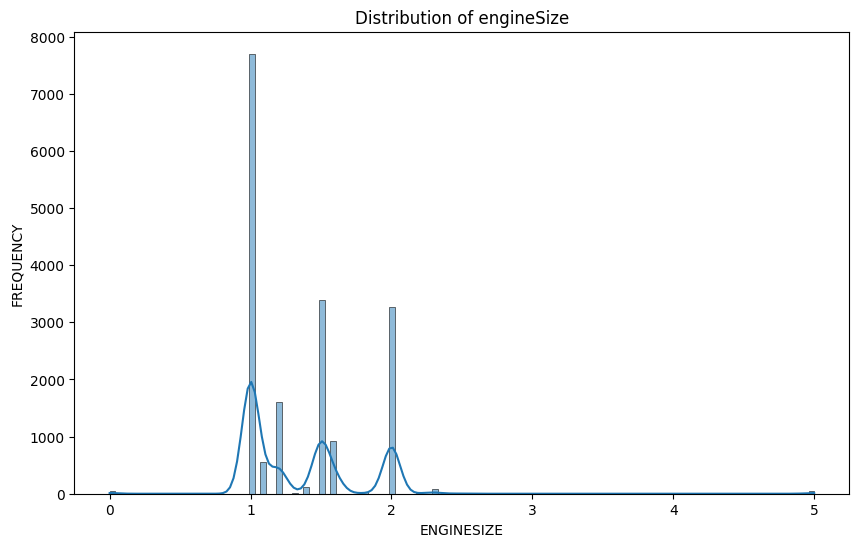

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col.upper())
    plt.ylabel('Frequency'.upper())
    plt.show()

**Categorical Features w.r.t Price(target variable)**

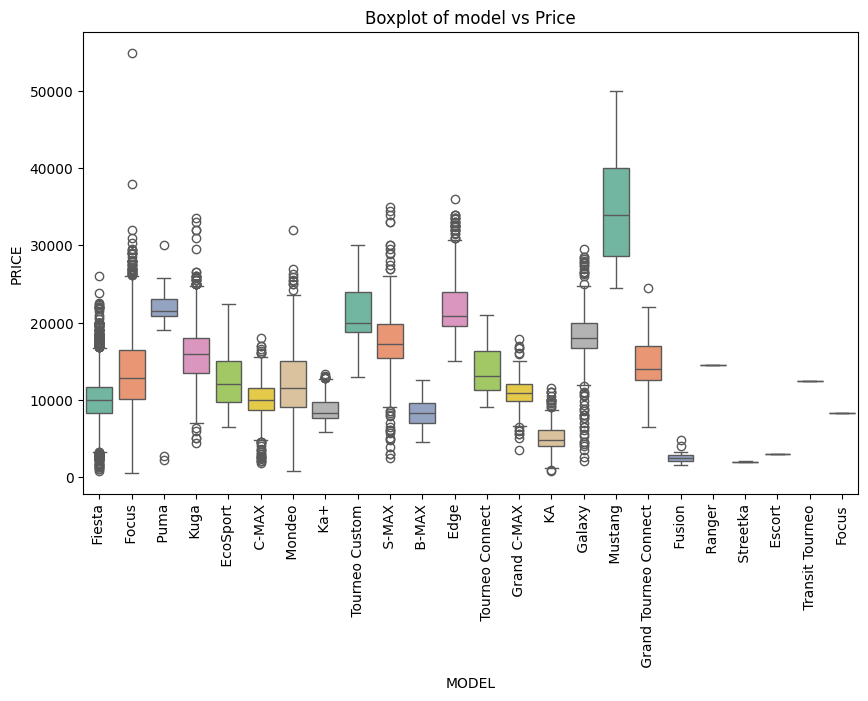

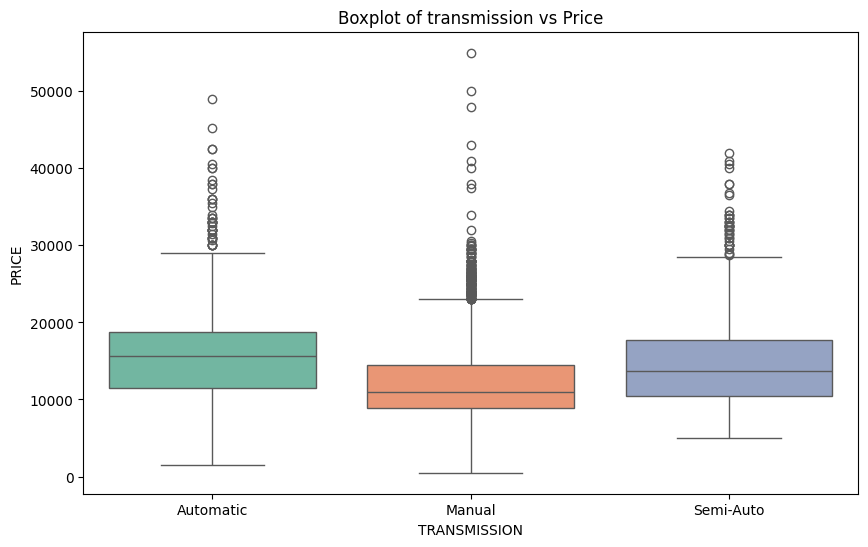

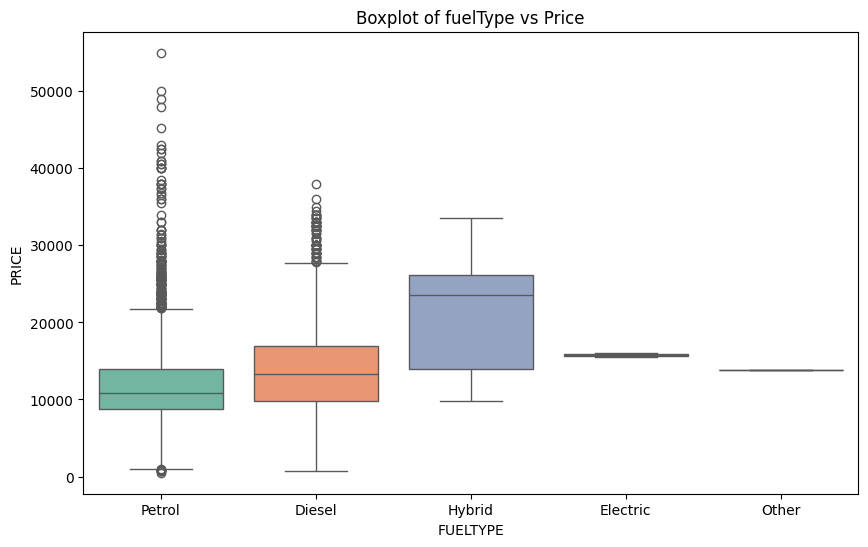

In [ ]:
for cols in cat_columns:
  plt.figure(figsize=(10, 6))
  sns.boxplot(data=df, x=cols, y=df['price'],palette='Set2')
  if cols == 'model':
    plt.xticks(rotation=90)
  plt.title(f'Boxplot of {cols} vs Price')
  plt.xlabel(cols.upper())
  plt.ylabel('Price'.upper())
  plt.show()

**Numeric Features w.r.t Price(target variable)**

<Axes: xlabel='mileage', ylabel='price'>

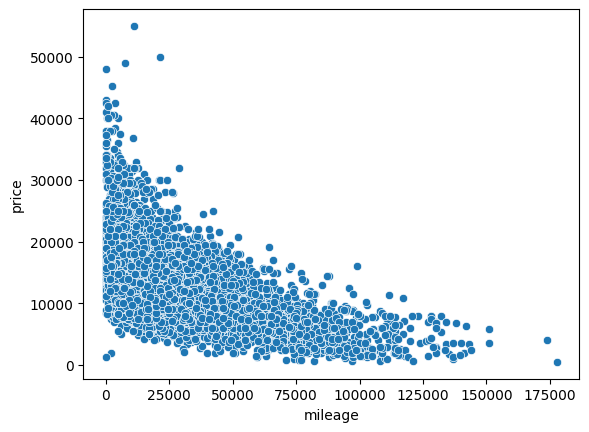

In [ ]:
sns.scatterplot(data=df, x=df['mileage'], y=df['price'])

<Axes: xlabel='mpg', ylabel='price'>

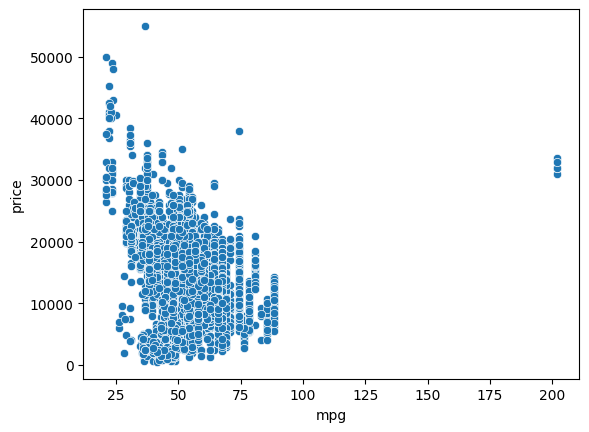

In [ ]:
sns.scatterplot(data=df, x=df['mpg'], y=df['price'])

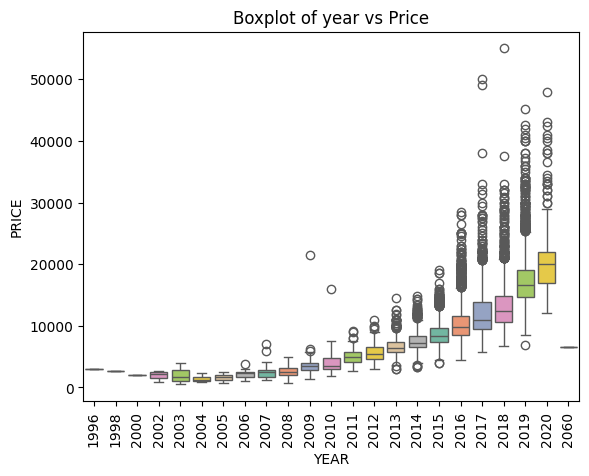

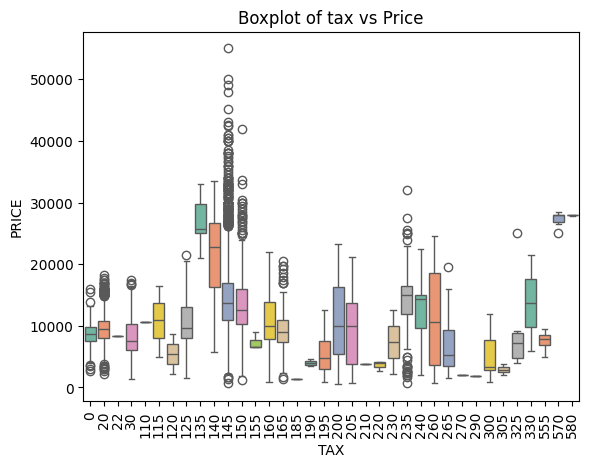

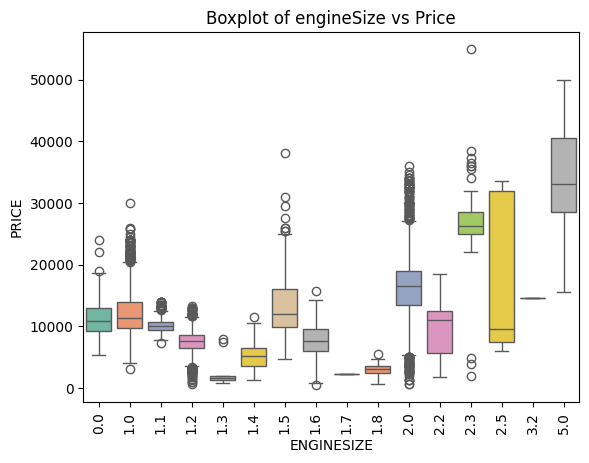

In [ ]:
columns = ['year','tax','engineSize']
for cols in columns:
  sns.boxplot(data=df, x=cols, y=df['price'],palette='Set2')
  plt.title(f'Boxplot of {cols} vs Price')
  plt.xlabel(cols.upper())
  plt.ylabel('Price'.upper())
  plt.xticks(rotation=90)
  plt.show()


**Data Preprocessing**

I'll use Label and One hot Encoding separately on same dataset and train individual two Regression models

In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [ ]:
X = df.drop(columns=['price'])
y = df['price']

**One Hot Encoding**

In [ ]:
one_hot_enc = X.copy()

In [ ]:
one_hot_enc = pd.get_dummies(X)

In [ ]:
one_hot_enc.head()

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
from sklearn.preprocessing import StandardScaler

columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

scaler = StandardScaler()
one_hot_enc[columns] = scaler.fit_transform(one_hot_enc[columns])
one_hot_enc.head()

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,0.554393,-0.736317,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0.067059,-0.562616,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,1.041726,-0.665405,0.510777,-1.737858,0.345325,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,1.041726,-1.127749,0.510777,-0.908836,-0.810561,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
one_hot_enc.astype(float)

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.020597,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.554393,-0.736317,0.591380,-0.020597,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.067059,-0.562616,0.591380,-0.020597,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.041726,-0.665405,0.510777,-1.737858,0.345325,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.041726,-1.127749,0.510777,-0.908836,-0.810561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591380,-1.066745,0.114148,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
17962,-1.394942,0.891875,-1.343079,-0.020597,-0.810561,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
17963,-0.907608,-0.843071,-1.504284,0.926858,0.576502,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
17964,0.554393,-0.946220,0.510777,-0.020597,-0.348206,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
one_hot_enc.head()

,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,0.554393,-0.736317,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,0.067059,-0.562616,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,1.041726,-0.665405,0.510777,-1.737858,0.345325,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,1.041726,-1.127749,0.510777,-0.908836,-0.810561,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


**Label Encoding**

In [ ]:
label_enc = X.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_columns = ['model', 'transmission', 'fuelType']
for col in cat_columns:
  label_enc[col] = le.fit_transform(label_enc[col])

In [ ]:
label_enc.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [ ]:
label_enc.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

columns = ['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()

label_enc[columns]= scaler.fit_transform(label_enc[columns])

In [ ]:
label_enc.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460281,0.067059,-2.667947,-0.382994,0.688206,0.591380,-0.020597,-0.810561
1,-0.210828,0.554393,0.042455,-0.736317,0.688206,0.591380,-0.020597,-0.810561
2,-0.210828,0.067059,0.042455,-0.562616,0.688206,0.591380,-0.020597,-0.810561
3,-0.460281,1.041726,0.042455,-0.665405,0.688206,0.510777,-1.737858,0.345325
4,-0.460281,1.041726,-2.667947,-1.127749,0.688206,0.510777,-0.908836,-0.810561


**Features(columns) in both Encoding**

In [ ]:
one_hot_enc.shape

(17812, 37)

In [ ]:
label_enc.shape

(17812, 8)

**Model Training**

**One Hot Enc Data Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

`one_hot_enc == X`

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(one_hot_enc, y, test_size=0.33, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([22278.48807031, 15424.63681985, 16113.81442332, ...,
       14958.80564248, 12402.09760744, 15115.56707688])

In [ ]:
y_test

,price
9891,22975
13006,18000
15284,18500
6399,9985
8182,7998
...,...
12200,10470
7226,13998
11523,15199
13684,12290


In [ ]:
r2 = r2_score(y_test,y_pred)
r2

0.8265046198596344

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1-((1-r2)*(n-1)) / (n-p-1)
adj_r2

0.8254054196772382

**Label Enc Data Model**

`label_enc == X`

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(label_enc, y, test_size=0.33, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([16540.94185432, 15076.66531175, 16754.43591901, ...,
       13428.26494596, 13136.81760351, 13571.38462746])

In [ ]:
y_test

,price
9891,22975
13006,18000
15284,18500
6399,9985
8182,7998
...,...
12200,10470
7226,13998
11523,15199
13684,12290


In [ ]:
r2 = r2_score(y_test,y_pred)
r2

0.7167444123752094

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1-((1-r2)*(n-1)) / (n-p-1)
adj_r2

0.7163583083198339

**Result:** Although Label Encoding and One-Hot Encoding are often used together on the same dataset, One-Hot Encoding is generally preferred for nominal categorical features because it creates a separate feature for each category. This provides a clearer representation of the data, making it easier for the model to understand patterns and relationships.

---

**Nominal Features**

* **Order:** No specific order (Random categories)
* **Examples:** Gender, Color, City, Blood Group
* **Preferred Encoding:** One-Hot Encoding

**Ordinal Features**

* **Order:** Has a specific order or ranking
* **Examples:** T-Shirt Size (S, M, L, XL), Education Level, Ratings (Poor, Good, Excellent)
* **Preferred Encoding:** Label Encoding (Ordinal Encoding)
